**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [13]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor
from textwrap import wrap
from feature_engine.selection import DropCorrelatedFeatures

First, let's import datasets and y-target, created earlier:

In [2]:
with open ('padel_descks.pickle', 'rb') as inp:
    padel_descs = pickle.load(inp)

In [3]:
with open ('rdkit_descs.pickle', 'rb') as inp:
    rdkit_descs = pickle.load(inp)

In [4]:
united_descs = {}
united_descs['United_ionic'] = pd.concat([padel_descs['Padel_ionic'], rdkit_descs['RDKIt_ionic']], axis = 1)
united_descs['United_non_ionic'] = pd.concat([padel_descs['Padel_non_ionic'], rdkit_descs['RDKIt_non_ionic']], axis = 1)
united_descs['United_extended'] = pd.concat([padel_descs['Padel_extended'], rdkit_descs['RDKIt_extended']], axis = 1)

In [5]:
features_to_drop_united = {}
for key, value in united_descs.items():
    dropper = DropCorrelatedFeatures(threshold=0.8)
    print('Initial number of descriptors for', key, 'is ', len(value.columns))
    value = value.loc[:, ~value.columns.duplicated()].copy()
    v_dropped = dropper.fit_transform(value)
    print('Final number of descriptors for', key, 'is ', len(v_dropped.columns))
    united_descs[key] = v_dropped
    features_to_drop_united[key] = dropper.features_to_drop_

Initial number of descriptors for United_ionic is  830
Final number of descriptors for United_ionic is  788
Initial number of descriptors for United_non_ionic is  821
Final number of descriptors for United_non_ionic is  778
Initial number of descriptors for United_extended is  864
Final number of descriptors for United_extended is  841


In [6]:
with open('features_to_drop_united.pickle', 'wb') as out:
    pickle.dump(features_to_drop_united, out)

In [7]:
with open('united_descs.pcikle', 'wb') as out:
    pickle.dump(united_descs, out)

In [8]:
data_ionic = pd.read_csv('Data_ionic.csv')
target_ionic = data_ionic['Cc ']

data_extended = pd.read_csv('Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'United_ionic': target_ionic, 'United_non_ionic': target_non_ionic, 'United_extended':target_extended}

In [38]:
scores_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'United_ionic': scores_ionic, 'United_non_ionic': scores_non_ionic, 'United_extended':scores_extended}

In [39]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

In [40]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = united_descs, targets = targets, n_iters = 150):
    fig, axes = plt.subplots(1, 3, figsize = (12,8))
    i = 0
    
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=5)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']
        
        scores[key]['Descriptors'].append('United')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)
        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('All_classes_United_{}_scattter.png'.format(estimator_name))

Subfunction below is to retrieve best model from Trials object ans is used in main functions

Let's initialize scores dictionary and test function with Logistic Regression

100%|██████████████████████████████████████████████| 150/150 [01:52<00:00,  1.33trial/s, best loss: 1.7131765271731485]
{'alpha': 19.52185785299944, 'solver': 1}
100%|██████████████████████████████████████████████| 150/150 [02:33<00:00,  1.03s/trial, best loss: 1.1522556692418786]
{'alpha': 31.09801537710687, 'solver': 1}
100%|██████████████████████████████████████████████| 150/150 [00:43<00:00,  3.42trial/s, best loss: 0.9948897082352322]
{'alpha': 99.97466845704827, 'solver': 2}


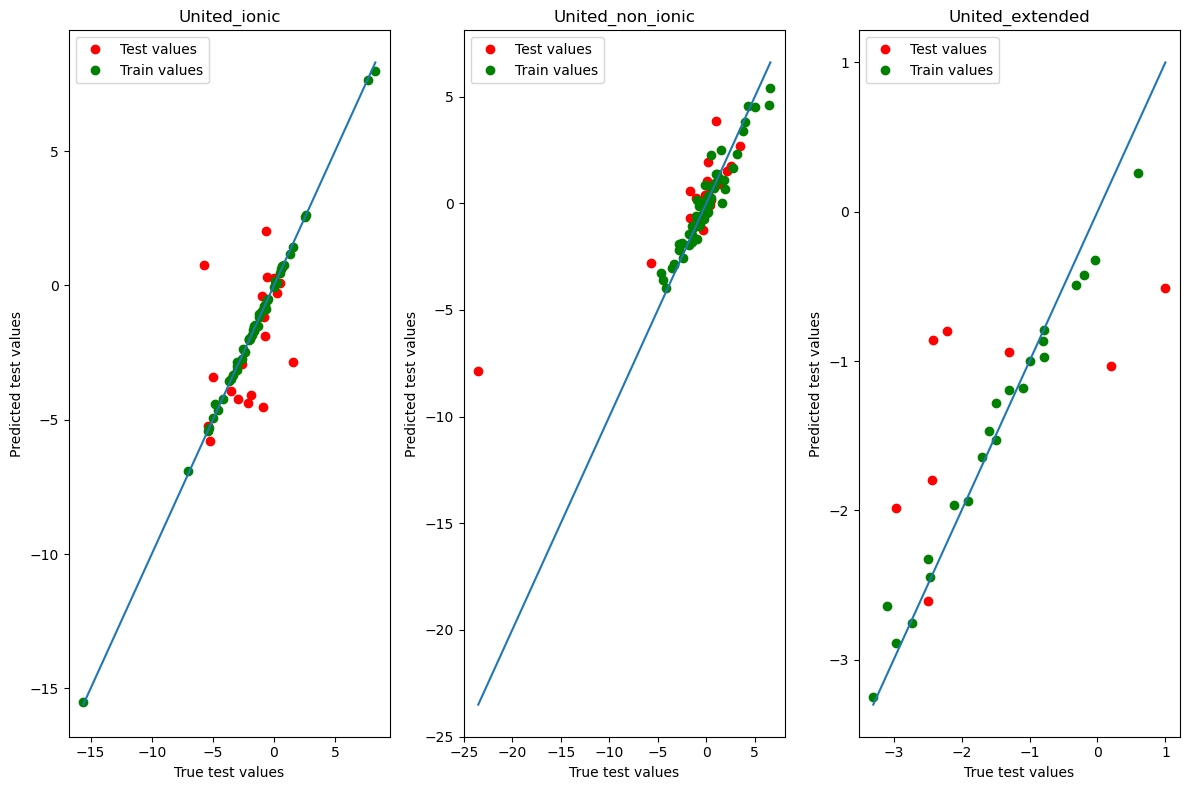

In [41]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])}, n_iters=150)

Let's continue with other models. The first one will be
**Random Forest Classification**

In [42]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|███████████████████████████████████████████████| 150/150 [06:50<00:00,  2.74s/trial, best loss: 1.699511913491407]
{'bootstrap': 0, 'ccp_alpha': 0.07208425368164159, 'criterion': 0, 'max_depth': 4, 'max_features': 1, 'max_samples': 0.9024914099404985, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 157}
100%|███████████████████████████████████████████████| 150/150 [06:37<00:00,  2.65s/trial, best loss: 1.247558193971304]
{'bootstrap': 0, 'ccp_alpha': 0.02925861166588306, 'criterion': 0, 'max_depth': 4, 'max_features': 0, 'max_samples': 0.8984099300177103, 'min_samples_leaf': 4, 'min_samples_split': 13, 'n_estimators': 156}
100%|██████████████████████████████████████████████| 150/150 [06:38<00:00,  2.66s/trial, best loss: 0.7921309445074326]
{'bootstrap': 0, 'ccp_alpha': 0.0028466779232463723, 'criterion': 0, 'max_depth': 5, 'max_features': 1, 'max_samples': 0.6112022930131754, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 84}


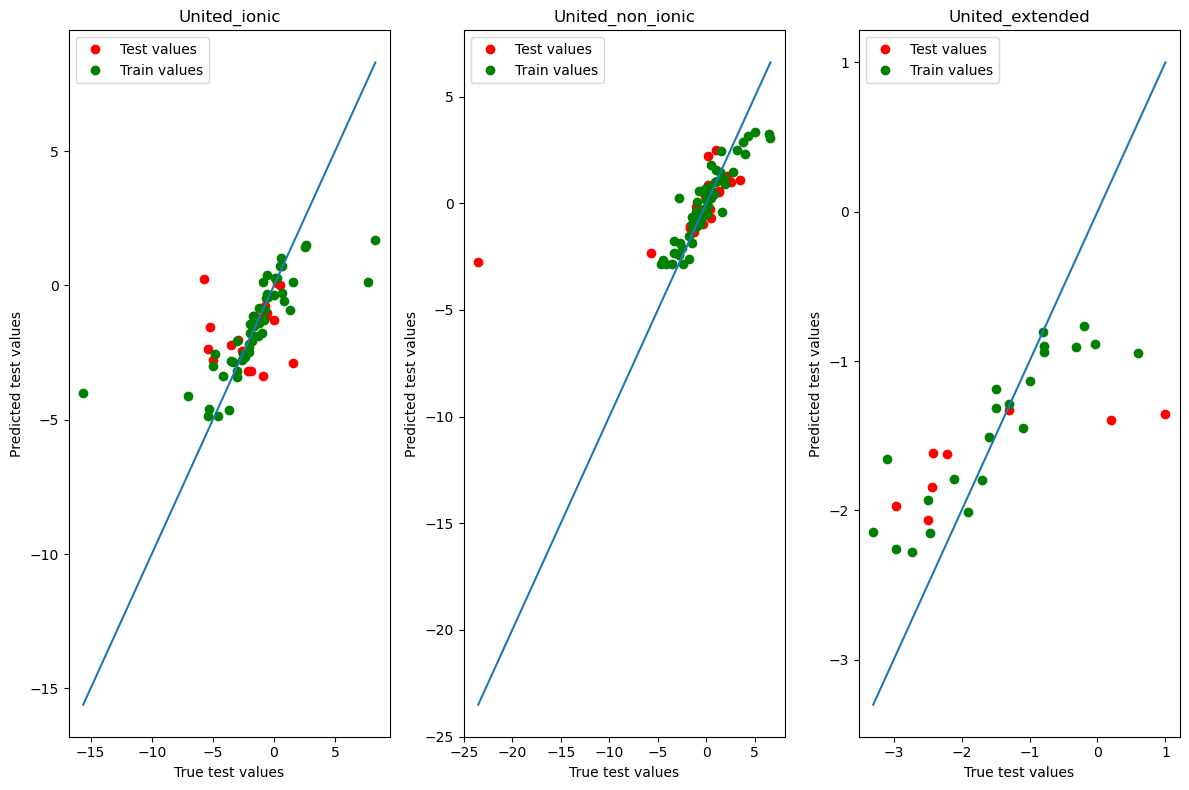

In [43]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [44]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|██████████████████████████████████████████████| 150/150 [02:17<00:00,  1.09trial/s, best loss: 1.7019529886936577]
{'boosting_type': 0, 'learning_rate': 0.013797756905954717, 'max_depth': 11, 'min_child_samples': 8, 'n_estimators': 73, 'n_leaves': 38, 'reg_alpha': 0.007127547662630005, 'reg_lambda': 0.8402966297730352}
100%|██████████████████████████████████████████████| 150/150 [02:01<00:00,  1.24trial/s, best loss: 1.0401069084277519]
{'boosting_type': 0, 'learning_rate': 0.6824729290397661, 'max_depth': 9, 'min_child_samples': 8, 'n_estimators': 228, 'n_leaves': 30, 'reg_alpha': 0.0018064829311606237, 'reg_lambda': 0.08838151175795667}
100%|██████████████████████████████████████████████| 150/150 [01:09<00:00,  2.15trial/s, best loss: 0.8394968848321934]
{'boosting_type': 0, 'learning_rate': 0.0016084326217848499, 'max_depth': 10, 'min_child_samples': 5, 'n_estimators': 265, 'n_leaves': 32, 'reg_alpha': 0.038092964319590035, 'reg_lambda': 0.16529333584832376}


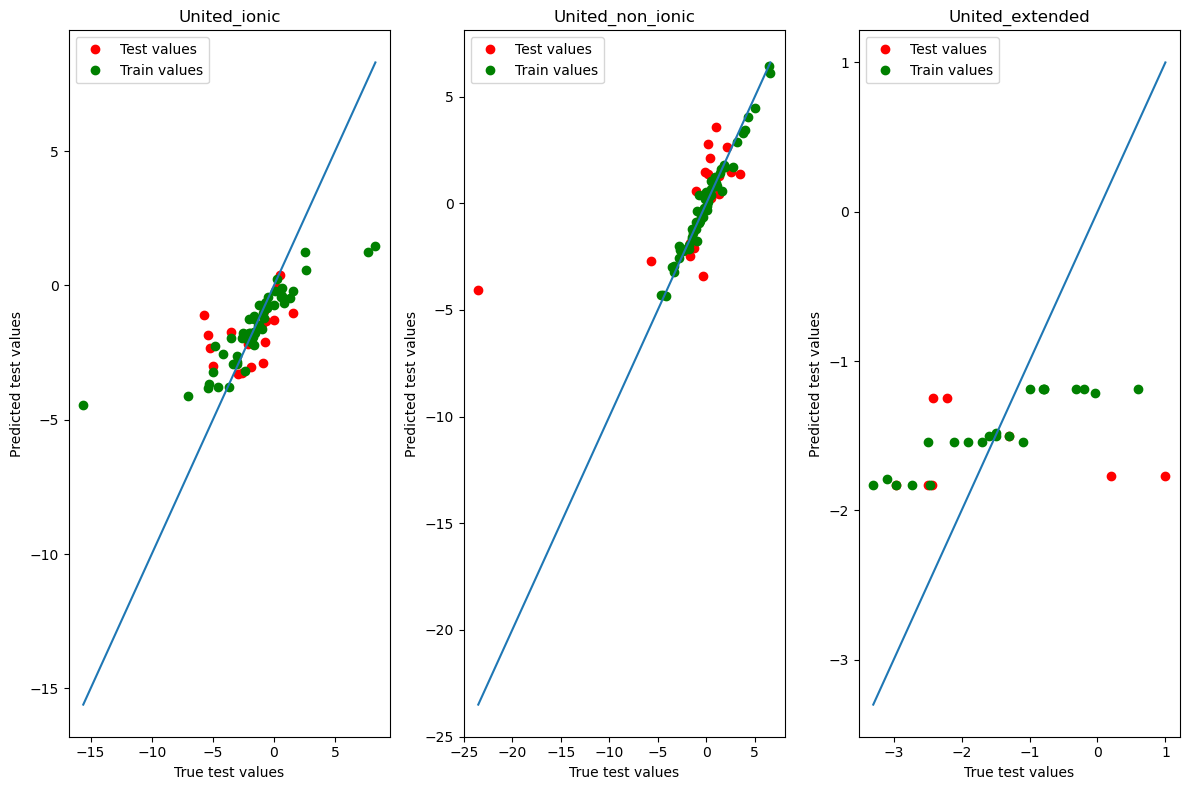

In [45]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [46]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|██████████████████████████████████████████████| 500/500 [02:08<00:00,  3.89trial/s, best loss: 1.3759460527958665]
{'C': 9.998501103482655, 'coef0': 0.4350239417218773, 'degree': 1, 'gamma': 0, 'kernel': 1}
100%|██████████████████████████████████████████████| 500/500 [02:09<00:00,  3.87trial/s, best loss: 1.1266413978110879]
{'C': 9.941714404568915, 'coef0': 0.7020428583154218, 'degree': 2, 'gamma': 1, 'kernel': 1}
100%|██████████████████████████████████████████████| 500/500 [02:02<00:00,  4.08trial/s, best loss: 0.8190985078515775]
{'C': 3.79663664186357, 'coef0': 1.805038669534873, 'degree': 0, 'gamma': 0, 'kernel': 3}


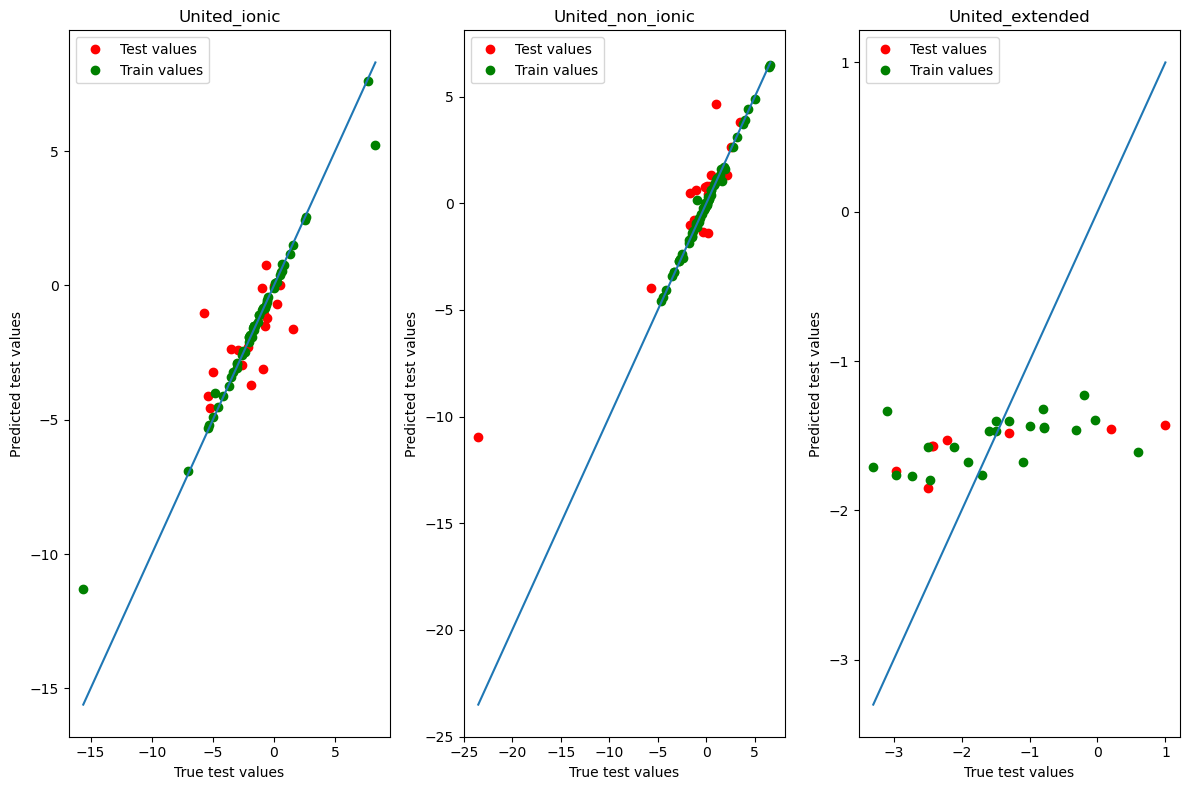

In [47]:
calculate_to_score(SVR(max_iter = 25000), estimator_name = 'SVR', param_grid = space, n_iters = 500)
                                                                


In [ ]:
pd.DataFrame(scores_ionic)

**KNearestneighbors**

In [48]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|██████████████████████████████████████████████| 150/150 [00:37<00:00,  4.00trial/s, best loss: 1.5713224123788914]
{'algorithm': 0, 'leaf_size': 21, 'metric': 1, 'n_neighbors': 4, 'p': 2.7936362543993507, 'weights': 1}
100%|██████████████████████████████████████████████| 150/150 [00:38<00:00,  3.91trial/s, best loss: 1.3596475555555556]
{'algorithm': 0, 'leaf_size': 18, 'metric': 1, 'n_neighbors': 4, 'p': 2.8836886335782963, 'weights': 0}
100%|██████████████████████████████████████████████| 150/150 [00:37<00:00,  4.00trial/s, best loss: 0.7814799569271323]
{'algorithm': 1, 'leaf_size': 33, 'metric': 2, 'n_neighbors': 3, 'p': 1.032609843937205, 'weights': 1}


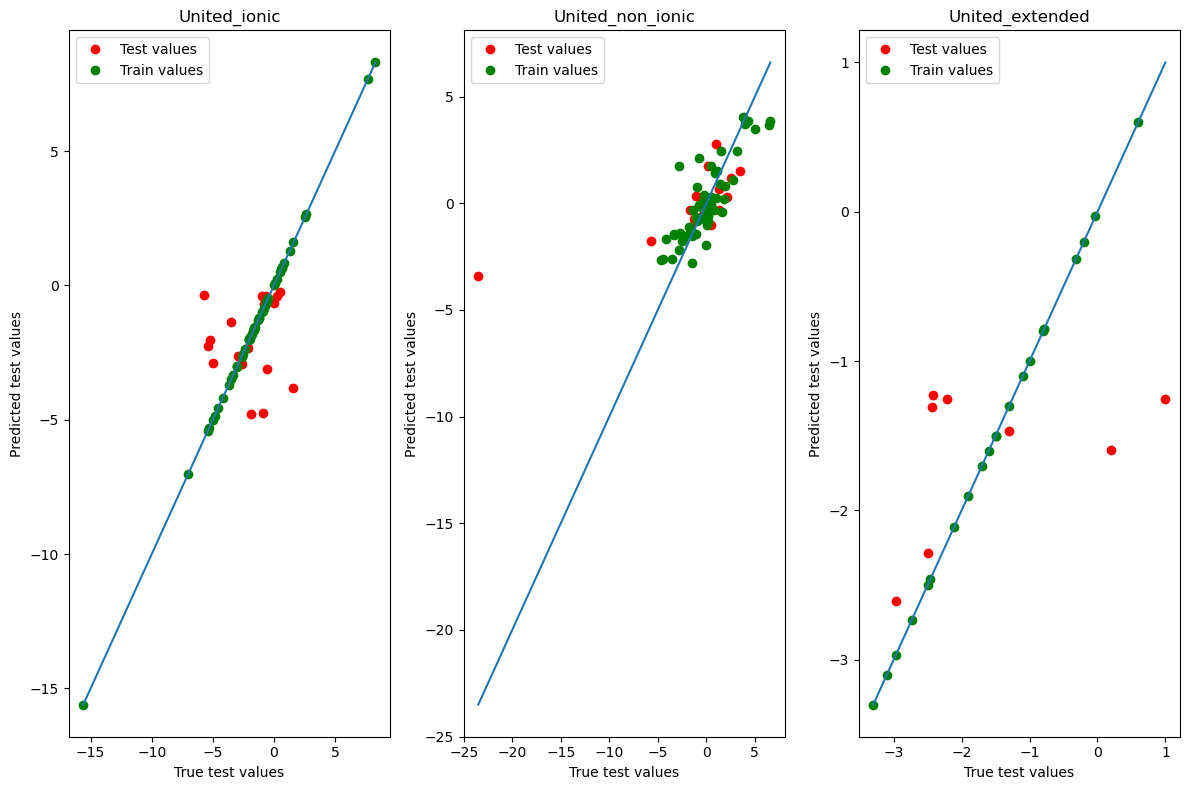

In [50]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [45]:
with open('scores_united_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [51]:
pd.DataFrame(scores_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,-0.283556,1.713177,1.935815,-0.172976,2.289160,1.590479,0.998802,0.114478,0.077639
1,United,Random Forest,-0.029095,1.699512,1.831783,-0.142350,2.259079,1.561460,0.534478,2.256785,1.064673
2,United,Gradient boosting,-0.018779,1.701953,1.827174,0.225101,1.860606,1.369522,0.551251,2.215755,1.140972
3,United,SVR,0.116952,1.375946,1.763015,0.387315,1.654437,1.214865,0.950673,0.734617,0.234760
4,United,KMeans,0.114645,1.571322,1.764166,-0.393655,2.495223,1.823492,1.000000,0.000000,0.000000
5,United,KMeans,0.114645,1.571322,1.764166,-0.393655,2.495223,1.823492,1.000000,0.000000,0.000000


In [52]:
pd.DataFrame(scores_extended)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,-0.010318,0.994890,1.020493,0.326599,1.105681,0.977026,0.970938,0.176625,0.131686
1,United,Random Forest,0.059739,0.792131,1.002323,0.269777,1.151386,0.924615,0.628074,0.631857,0.458717
2,United,Gradient boosting,-0.042353,0.839497,1.028488,-0.101740,1.414271,1.187354,0.369235,0.822858,0.658512
3,United,SVR,-0.046257,0.819099,1.029449,0.134151,1.253759,1.069601,0.132723,0.964872,0.767830
4,United,KMeans,0.123172,0.781480,0.984972,0.164027,1.231938,1.010896,1.000000,0.000000,0.000000
5,United,KMeans,0.123172,0.781480,0.984972,0.164027,1.231938,1.010896,1.000000,0.000000,0.000000


In [53]:
pd.DataFrame(scores_non_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,0.497852,1.152256,1.321546,0.536104,3.812256,1.809012,0.919569,0.698974,0.544642
1,United,Random Forest,0.430267,1.247558,1.363931,0.224138,4.930191,2.115293,0.793156,1.120908,0.801152
2,United,Gradient boosting,0.360379,1.040107,1.403961,0.282579,4.740875,2.293275,0.971452,0.416424,0.316295
3,United,SVR,0.472476,1.126641,1.337935,0.683003,3.151368,1.583250,0.993596,0.197237,0.127823
4,United,KMeans,0.401964,1.327692,1.380563,0.261744,4.809223,2.080555,1.000000,0.000000,0.000000
5,United,KMeans,0.413636,1.359648,1.373777,0.253453,4.836156,2.168175,0.699094,1.351961,1.028857
